[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dataset shape: (973, 17)
               Company Know to use the "Double Irish Arrangement"?  \
0  Abbott Laboratories                                         Yes   
1                Adobe                                         Yes   
2             Allergan                                         Yes   
3                Apple                                         Yes   
4            Eli Lilly                                         Yes   

  Discloses Likely Tax Payments from Repatriation Citizen for Tax Justice ID  \
0                                              No                Abbott Lab.   
1                                             NaN                        NaN   
2                                             NaN                        NaN   
3                                             Yes                 Apple Inc.   
4                                             Yes      Eli Lilly and Company   

              Category                                        Description

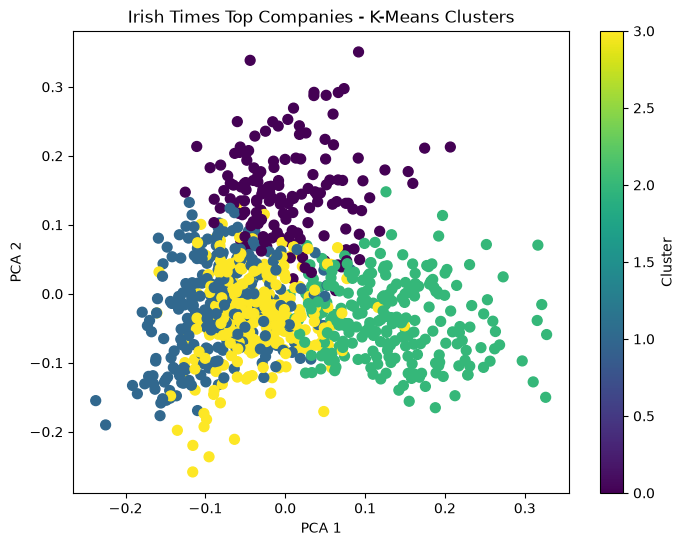


Clustered dataset saved successfully.


In [1]:
# ============================================
# Irish Times Top Companies - NLP + K-Means
# ============================================

# 1. Import libraries
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Download NLP resources
nltk.download("stopwords")
nltk.download("wordnet")

# 2. Load dataset
df = pd.read_csv("Irish Times Top Companies.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns)

# 3. Select text column
# Change this if your dataset uses a different column name
text_column = "Description"

df[text_column] = df[text_column].fillna("").astype(str)

# 4. NLP text cleaning
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

df["clean_text"] = df[text_column].apply(clean_text)

# 5. Convert text to TF-IDF
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["clean_text"])

print("TF-IDF shape:", X.shape)

# 6. K-Means clustering
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

# 7. Show cluster sizes
print("\nCompanies per cluster:")
print(df["Cluster"].value_counts().sort_index())

# 8. Silhouette score
score = silhouette_score(X, df["Cluster"])
print("\nSilhouette Score:", round(score, 3))

# 9. Show important words for each cluster
terms = tfidf.get_feature_names_out()

print("\nTop words in each cluster:")

for i in range(k):
    top_words = kmeans.cluster_centers_[i].argsort()[-10:][::-1]
    words = [terms[j] for j in top_words]

    print(f"\nCluster {i}:")
    print(", ".join(words))

# 10. PCA visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Irish Times Top Companies - K-Means Clusters")
plt.colorbar(label="Cluster")
plt.show()

# 11. Save results
df.to_csv(
    "Irish_Times_Top_Companies_Clustered.csv",
    index=False
)

print("\nClustered dataset saved successfully.")